# Held-Out Test: `TodPennnyOIThresholdStrategy`

This notebook runs the final held-out workflow only:

1. Fit `TodPennnyOIThresholdStrategy` on all of `data-train`
2. Evaluate the frozen fitted strategy on all of `data-test`

It does not use the internal `train_frac` split from the development pipeline.

## Colab Setup

This cell prepares a clean Colab environment. It clones the repo into `/content/optimal-execution`, mounts Google Drive, copies the held-out `train` and `test` CSV folders into `data-train` and `data-test`, and installs the Python dependencies needed to run the notebook.

If you are running locally and already have the repo plus data directories set up, skip this cell.

In [33]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not IN_COLAB:
    print('Local environment detected. Skip this cell if your repo and data are already set up.')
else:
    drive.mount('/content/drive')
    os.chdir('/content')

    repo_dir = Path('/content/optimal-execution')
    if repo_dir.exists():
        shutil.rmtree(repo_dir)

    subprocess.run(
        ['git', 'clone', 'https://github.com/MatteoPerona/optimal-execution.git'],
        check=True,
    )
    os.chdir(repo_dir)
    subprocess.run(['git', 'checkout', 'testing'], check=True)

    shutil.rmtree('data-train', ignore_errors=True)
    shutil.rmtree('data-test', ignore_errors=True)
    shutil.copytree('/content/drive/MyDrive/cs5259data/train', 'data-train')
    shutil.copytree('/content/drive/MyDrive/cs5259data/test', 'data-test')

    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'pandas', 'numpy', 'scipy', 'matplotlib', 'jupyter', 'ipython'],
        check=True,
    )

    print(f'Working directory: {Path.cwd()}')
    print('Train files:', sorted(os.listdir('data-train'))[:5])
    print('Test files:', sorted(os.listdir('data-test'))[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/optimal-execution
Train files: ['AAPL_5levels_train.csv', 'AMZN_5levels_train.csv', 'GOOG_5levels_train.csv', 'INTC_5levels_train.csv', 'MSFT_5levels_train.csv']
Test files: ['AAPL_5levels_test.csv', 'AMZN_5levels_test.csv', 'GOOG_5levels_test.csv', 'INTC_5levels_test.csv', 'MSFT_5levels_test.csv']


In [34]:
import os
from pathlib import Path

repo_root = Path.cwd()
if repo_root.name == 'heldout_test':
    repo_root = repo_root.parent
elif repo_root.name != 'optimal-execution' and (repo_root / 'optimal-execution').exists():
    repo_root = repo_root / 'optimal-execution'

os.chdir(repo_root)
print(f'Working directory: {Path.cwd()}')

import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

from utils.config import DEFAULT_CONFIG
from utils.strategy import TodPennnyOIThresholdStrategy
from utils.evaluation import print_results, plot_results, evaluate_both_sides, evaluate_strategy
from heldout_test import run_external_test_experiment

Working directory: /content/optimal-execution


In [35]:
heldout_config = DEFAULT_CONFIG.copy()
heldout_config['stocks'] = ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
heldout_config['train_data_dir'] = 'data-train'
heldout_config['test_data_dir'] = 'data-test'

heldout_config

{'stocks': ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT'],
 'data_dir': 'data',
 'penny_spread_cutoff': 0.02,
 'train_frac': 0.7,
 'imb_grid': (0.52, 0.95, 30),
 'spread_grid_penny': (0.005, 0.03, 20),
 'spread_grid_wide': (0.05, 0.5, 20),
 'smooth_size': 3,
 'horizons': (10, 20, 30, 60),
 'n_bins': 20,
 'train_data_dir': 'data-train',
 'test_data_dir': 'data-test'}

In [36]:
todpennny_heldout_results = run_external_test_experiment(
    TodPennnyOIThresholdStrategy,
    heldout_config,
    signal_fn='oi',
)

todpennny_heldout_results['fitted']

Running held-out test experiment: todpennny (signal=oi)
  train AAPL: wide
  train AMZN: wide
  train GOOG: wide
  train INTC: penny
  train MSFT: penny
  Train rows: 1,404,889
  Fitting parameters on full train set...
    wide: theta_imb=0.5200, theta_spread=0.1211
  Test rows:  705,971
  Backtesting on full held-out test set...


{('penny', 570): {'theta_imb': 0.982227331648816,
  'theta_spread': 0.016243429580749695},
 ('penny', 571): {'theta_imb': 0.9795848492989915,
  'theta_spread': 0.015860965030117198},
 ('penny', 572): {'theta_imb': 0.9728056006511115,
  'theta_spread': 0.014879757988976686},
 ('penny', 573): {'theta_imb': 0.9675418448974122,
  'theta_spread': 0.014117898603572833},
 ('penny', 574): {'theta_imb': 0.9654190786807414,
  'theta_spread': 0.013810656124844159},
 ('penny', 575): {'theta_imb': 0.9664611941570773,
  'theta_spread': 0.013961488627998037},
 ('penny', 576): {'theta_imb': 0.9682190431799703,
  'theta_spread': 0.014215914144469396},
 ('penny', 577): {'theta_imb': 0.9654384135241787,
  'theta_spread': 0.013813454589025874},
 ('penny', 578): {'theta_imb': 0.9677229237204635,
  'theta_spread': 0.01414410738059342},
 ('penny', 579): {'theta_imb': 0.9649463393606876,
  'theta_spread': 0.01374223332852059},
 ('penny', 580): {'theta_imb': 0.9654661126400729,
  'theta_spread': 0.013817463671

## Course Metric Table

This section computes the exact reported metric from the course email on both the full training set and the full held-out test set, using the same fitted `TodPennnyOIThresholdStrategy` parameters.

`100 - 100 * (TOTAL_YOURALGO_BUY - TOTAL_YOURALGO_SELL) / (TOTAL_TWAP_BUY - TOTAL_TWAP_SELL)`


In [37]:
def course_metric_from_side_results(buy_df, sell_df):
    total_twap_buy = buy_df['twap'].sum()
    total_twap_sell = sell_df['twap'].sum()
    total_algo_buy = (buy_df['twap'] - buy_df['strategy']).sum()
    total_algo_sell = (sell_df['twap'] + sell_df['strategy']).sum()

    denominator = total_twap_buy - total_twap_sell
    numerator = total_algo_buy - total_algo_sell
    metric = 100 - 100 * numerator / denominator

    return pd.Series({
        'n_buy_minutes': len(buy_df),
        'n_sell_minutes': len(sell_df),
        'total_twap_buy': total_twap_buy,
        'total_twap_sell': total_twap_sell,
        'total_algo_buy': total_algo_buy,
        'total_algo_sell': total_algo_sell,
        'total_improvement': buy_df['strategy'].sum() + sell_df['strategy'].sum(),
        'course_metric': metric,
    })

train_buy = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['train_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='buy',
)
train_sell = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['train_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='sell',
)
test_buy = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['test_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='buy',
)
test_sell = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['test_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='sell',
)

overall_metric_table = pd.DataFrame({
    'train': course_metric_from_side_results(train_buy, train_sell),
    'test': course_metric_from_side_results(test_buy, test_sell),
}).T
overall_metric_table


,n_buy_minutes,n_sell_minutes,total_twap_buy,total_twap_sell,total_algo_buy,total_algo_sell,total_improvement,course_metric
train,1350.0,1350.0,388473.439311,388300.708582,388433.33,388339.50,78.900728,45.678455
test,600.0,600.0,171103.264143,171043.345504,171092.27,171063.04,30.688639,51.217183


In [38]:
def metric_by_stock(buy_df, sell_df, split_name):
    buy_parts = {ticker: grp for ticker, grp in buy_df.groupby('ticker')}
    sell_parts = {ticker: grp for ticker, grp in sell_df.groupby('ticker')}
    rows = []
    for ticker in sorted(set(buy_parts) | set(sell_parts)):
        buy_part = buy_parts.get(ticker, buy_df.iloc[0:0].copy())
        sell_part = sell_parts.get(ticker, sell_df.iloc[0:0].copy())
        row = course_metric_from_side_results(buy_part, sell_part).to_dict()
        row['split'] = split_name
        row['ticker'] = ticker
        row['archetype'] = (buy_part['archetype'].iloc[0] if len(buy_part) else sell_part['archetype'].iloc[0])
        rows.append(row)
    return pd.DataFrame(rows)

train_stock_metrics = metric_by_stock(train_buy, train_sell, 'train')
test_stock_metrics = metric_by_stock(test_buy, test_sell, 'test')
course_metric_table = pd.concat([train_stock_metrics, test_stock_metrics], ignore_index=True)
course_metric_table = course_metric_table.sort_values(['split', 'archetype', 'ticker']).reset_index(drop=True)
course_metric_table[['split', 'ticker', 'archetype', 'course_metric', 'total_improvement', 'n_buy_minutes', 'n_sell_minutes']]


,split,ticker,archetype,course_metric,total_improvement,n_buy_minutes,n_sell_minutes
0,test,INTC,penny,97.066786,1.323692,120.0,120.0
1,test,MSFT,penny,109.954725,1.546367,120.0,120.0
2,test,AAPL,wide,41.368214,5.983145,120.0,120.0
3,test,AMZN,wide,35.848947,4.889683,120.0,120.0
4,test,GOOG,wide,58.341585,16.945753,120.0,120.0
5,train,INTC,penny,105.951766,3.382330,270.0,270.0
6,train,MSFT,penny,116.638617,3.715361,270.0,270.0
7,train,AAPL,wide,54.424926,24.898692,270.0,270.0
8,train,AMZN,wide,40.963605,15.570451,270.0,270.0
9,train,GOOG,wide,37.937301,31.333895,270.0,270.0


## Submission-Ready Row

This section reshapes the computed train/test course metric into the stock order used in the course reporting sheet: Intel, Microsoft, Amazon, Google, Apple. Fill in your time slot and team names, then copy the row values into the shared table.


In [39]:
stock_name_map = {
    'INTC': 'Intel',
    'MSFT': 'Microsoft',
    'AMZN': 'Amazon',
    'GOOG': 'Google',
    'AAPL': 'Apple',
}
stock_order = ['Intel', 'Microsoft', 'Amazon', 'Google', 'Apple']
split_order = ['train', 'test']

submission_values = course_metric_table[['split', 'ticker', 'course_metric']].copy()
submission_values['stock_name'] = submission_values['ticker'].map(stock_name_map)
submission_values['metric_pct'] = submission_values['course_metric'].map(lambda x: f'{x:.2f}%')
submission_series = submission_values.set_index(['stock_name', 'split'])['metric_pct']
submission_series = submission_series.reindex(pd.MultiIndex.from_product([stock_order, split_order]))
submission_row = submission_series.to_frame().T
submission_row.columns = [f'{stock} {split.title()}' for stock, split in submission_row.columns]
submission_row.index = ['TodPennnyOIThresholdStrategy']
submission_row


,Intel Train,Intel Test,Microsoft Train,Microsoft Test,Amazon Train,Amazon Test,Google Train,Google Test,Apple Train,Apple Test
TodPennnyOIThresholdStrategy,105.95%,97.07%,116.64%,109.95%,40.96%,35.85%,37.94%,58.34%,54.42%,41.37%


Mean Improvement over TWAP ($)
  Penny  (n= 480, win_rate=70.8%)  todpennny: $+0.005979  First Tick: $+0.000771  Last Tick: $+0.000771
  Wide   (n= 720, win_rate=63.7%)  todpennny: $+0.038637  First Tick: $+0.003734  Last Tick: $+0.003581
  All    (n=1200, win_rate=66.6%)  todpennny: $+0.025574  First Tick: $+0.002549  Last Tick: $+0.002457

Mean Improvement (spread units)

  Penny (median spread = $0.0100):
    todpennny           : +0.5979 spread units
    First Tick          : +0.0771 spread units
    Last Tick           : +0.0771 spread units

  Wide (median spread = $0.1400):
    todpennny           : +0.2760 spread units
    First Tick          : +0.0267 spread units
    Last Tick           : +0.0256 spread units


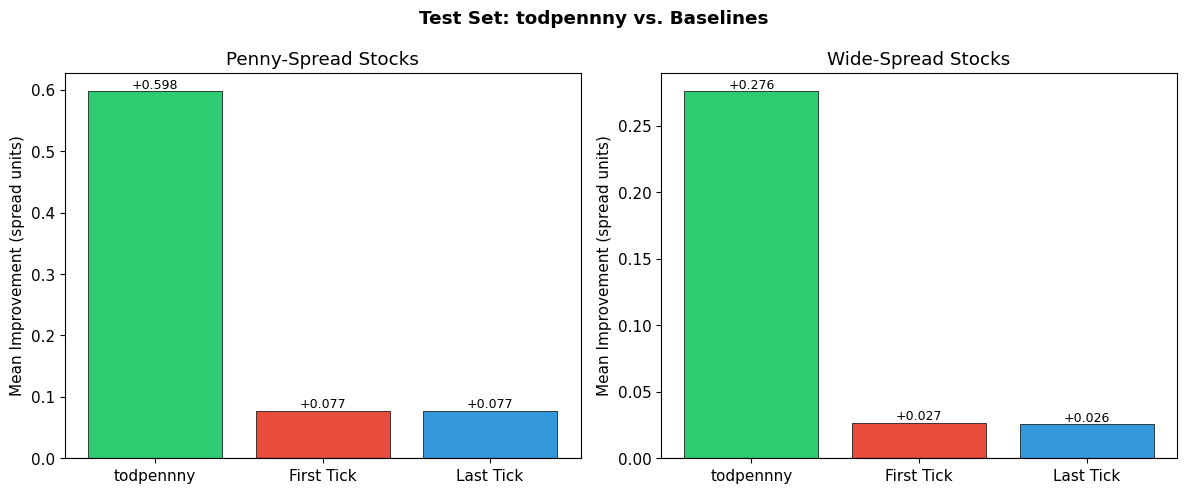

In [41]:
print_results(
    todpennny_heldout_results['test_all'],
    strategy_name='todpennny',
)
plot_results(
    todpennny_heldout_results['test_all'],
    strategy_name='todpennny',
)

## Stock-Level Held-Out Results

These cells break the final held-out test down by stock. They complement the archetype-level plots above with per-stock spread-unit, dollar, and win-rate views.

In [42]:
import numpy as np
import pandas as pd

heldout_test_all = todpennny_heldout_results['test_all'].copy()

stock_summary = (
    heldout_test_all
    .groupby(['ticker', 'archetype'], as_index=False)
    .agg(
        mean_improvement_dollars=('strategy', 'mean'),
        first_tick_dollars=('first_tick', 'mean'),
        last_tick_dollars=('last_tick', 'mean'),
        med_spread=('med_spread', 'median'),
        std_dollars=('strategy', 'std'),
        win_rate=('strategy', lambda s: (s > 0).mean()),
        n_minutes=('strategy', 'size'),
    )
)

stock_summary['mean_improvement_spreads'] = stock_summary['mean_improvement_dollars'] / stock_summary['med_spread']
stock_summary['first_tick_spreads'] = stock_summary['first_tick_dollars'] / stock_summary['med_spread']
stock_summary['last_tick_spreads'] = stock_summary['last_tick_dollars'] / stock_summary['med_spread']
stock_summary['std_spreads'] = stock_summary['std_dollars'] / stock_summary['med_spread']
stock_summary = stock_summary.sort_values(['archetype', 'ticker']).reset_index(drop=True)

stock_summary[[
    'ticker', 'archetype', 'mean_improvement_dollars', 'mean_improvement_spreads',
    'first_tick_spreads', 'last_tick_spreads', 'std_spreads', 'win_rate', 'n_minutes'
]].style.format({
    'mean_improvement_dollars': '{:.6f}',
    'mean_improvement_spreads': '{:.4f}',
    'first_tick_spreads': '{:.4f}',
    'last_tick_spreads': '{:.4f}',
    'std_spreads': '{:.4f}',
    'win_rate': '{:.1%}',
})


,ticker,archetype,mean_improvement_dollars,mean_improvement_spreads,first_tick_spreads,last_tick_spreads,std_spreads,win_rate,n_minutes
0,INTC,penny,0.005515,0.5515,0.0682,0.0682,0.7841,69.2%,240
1,MSFT,penny,0.006443,0.6443,0.0860,0.0860,0.9299,72.5%,240
2,AAPL,wide,0.024930,0.2077,0.0133,-0.0041,1.2324,59.6%,240
3,AMZN,wide,0.020374,0.1772,0.0043,-0.0029,0.6943,59.6%,240
4,GOOG,wide,0.070607,0.2824,0.0364,0.0463,0.5805,72.1%,240


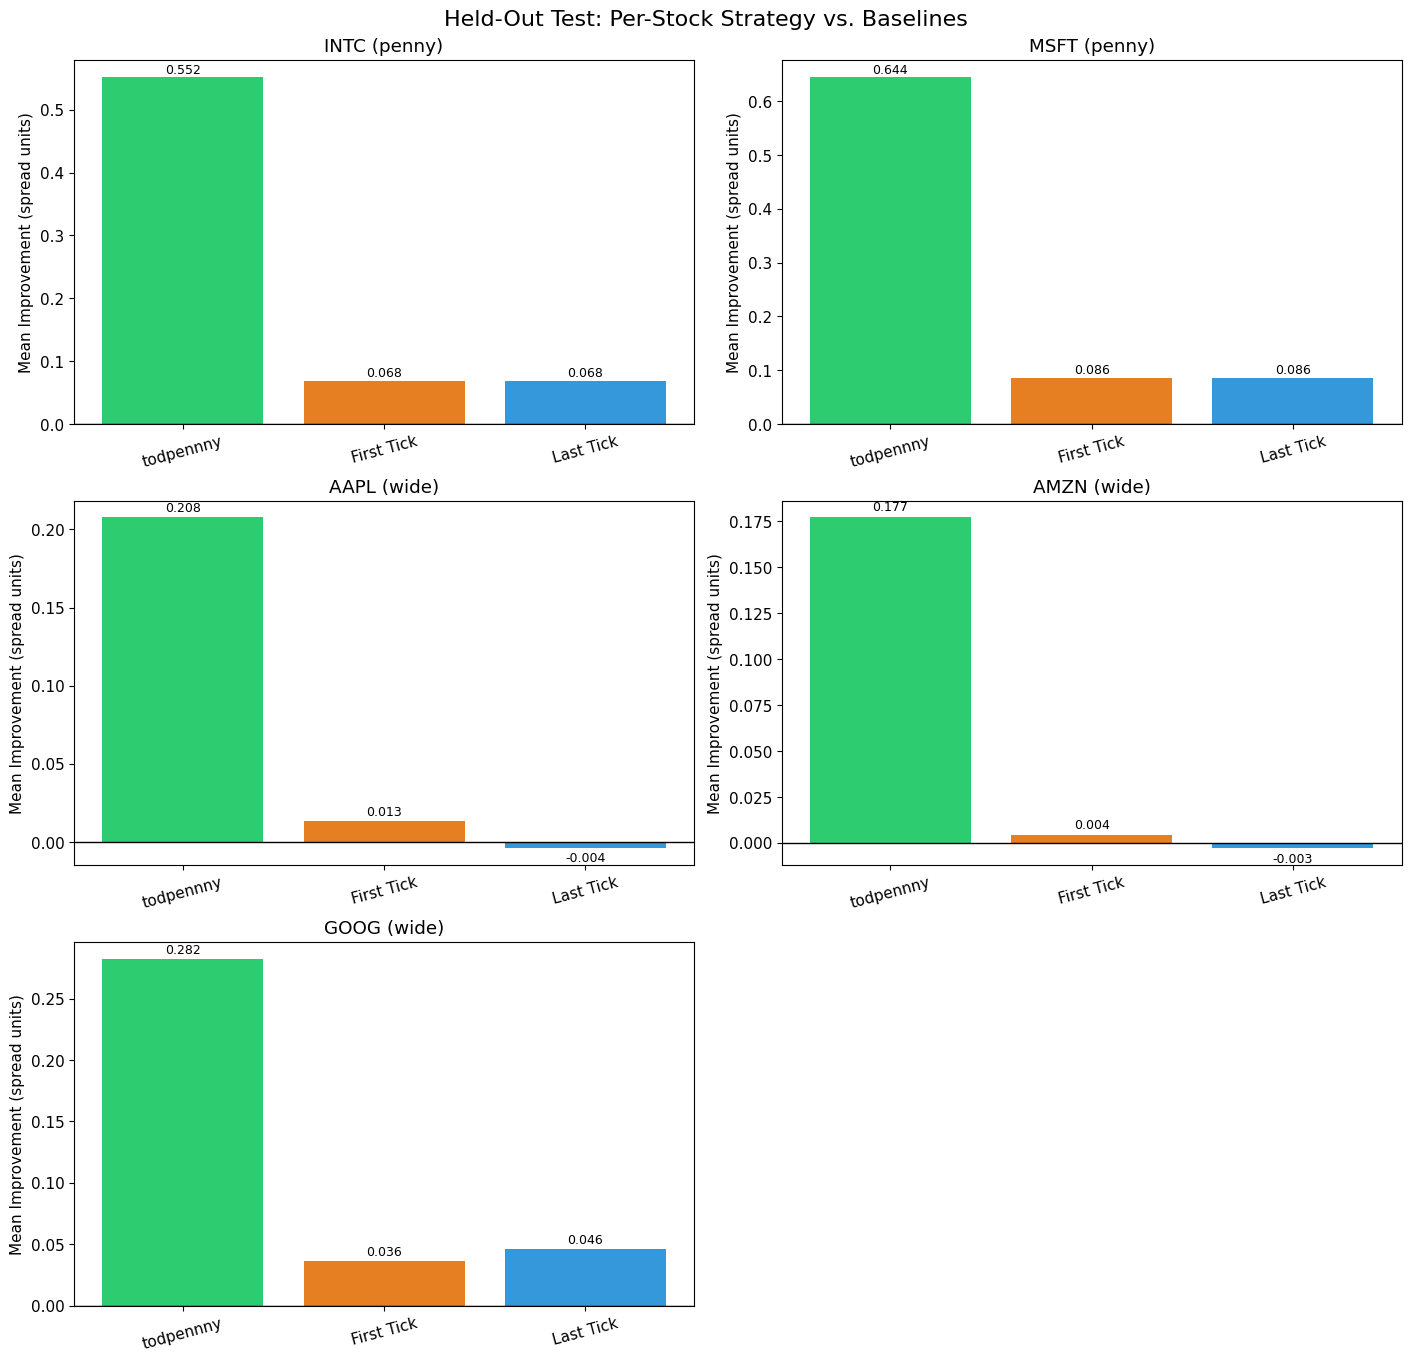

In [43]:
tickers = stock_summary['ticker'].tolist()
n = len(tickers)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, stock_summary.iterrows()):
    labels = ['todpennny', 'First Tick', 'Last Tick']
    values = [
        row['mean_improvement_spreads'],
        row['first_tick_spreads'],
        row['last_tick_spreads'],
    ]
    colors = ['#2ecc71', '#e67e22', '#3498db']
    bars = ax.bar(labels, values, color=colors)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f"{row['ticker']} ({row['archetype']})")
    ax.set_ylabel('Mean Improvement (spread units)')
    ax.tick_params(axis='x', rotation=15)

    for bar, value in zip(bars, values):
        offset = 0.002 if value >= 0 else -0.002
        va = 'bottom' if value >= 0 else 'top'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f'{value:.3f}',
            ha='center',
            va=va,
            fontsize=9,
        )

for ax in axes[n:]:
    ax.axis('off')

fig.suptitle('Held-Out Test: Per-Stock Strategy vs. Baselines', fontsize=16)
plt.show()


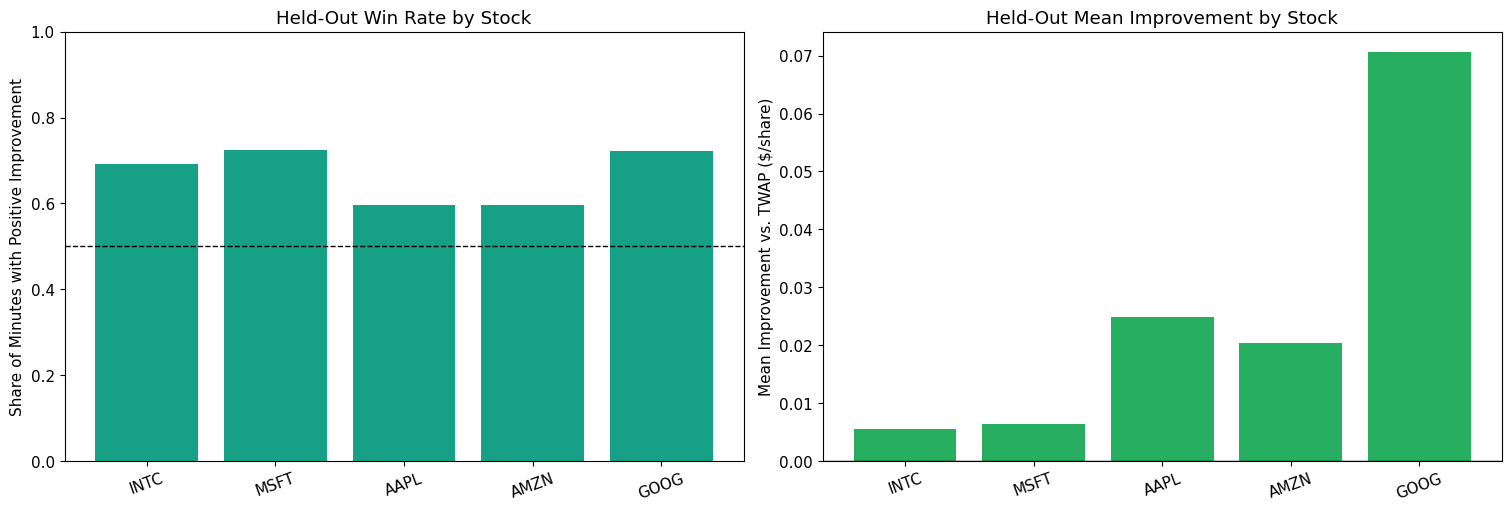

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

win_colors = ['#16a085' if x >= 0.5 else '#c0392b' for x in stock_summary['win_rate']]
axes[0].bar(stock_summary['ticker'], stock_summary['win_rate'], color=win_colors)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Held-Out Win Rate by Stock')
axes[0].set_ylabel('Share of Minutes with Positive Improvement')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

pnl_colors = ['#27ae60' if x >= 0 else '#c0392b' for x in stock_summary['mean_improvement_dollars']]
axes[1].bar(stock_summary['ticker'], stock_summary['mean_improvement_dollars'], color=pnl_colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Held-Out Mean Improvement by Stock')
axes[1].set_ylabel('Mean Improvement vs. TWAP ($/share)')
axes[1].tick_params(axis='x', rotation=20)

plt.show()
